In [1]:
import pandas as pd
df=pd.read_csv("loan_approval_tree_dataset_1500_rows.csv")
df

,income,credit_score,employment_years,loan_amount,debt_to_income,loan_approved
0,141958,747,20,271317,0.67,1
1,35795,799,20,376513,0.50,1
2,20860,314,13,293544,0.56,0
3,123694,588,19,186517,0.73,1
4,148106,777,13,75305,0.38,1
...,...,...,...,...,...,...
1495,112738,442,18,391350,0.19,1
1496,116646,490,10,177502,0.31,1
1497,103122,832,19,400203,0.65,1
1498,44519,526,2,161177,0.43,1


In [21]:
X = df.drop("loan_approved",axis=1)
y = df["loan_approved"]

In [22]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.25,random_state=42)

In [52]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
train_pred=model.predict(X_train)
test_pred=model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
accuracy_score(y_train,train_pred)

1.0

In [55]:
accuracy_score(y_test,test_pred)

0.9706666666666667

In [56]:
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train,y_train)
train_pred=model.predict(X_train)
test_pred=model.predict(X_test)

In [57]:
accuracy_score(y_train,train_pred)

0.9937777777777778

In [72]:
tree_acc =accuracy_score(y_test,test_pred)

In [73]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

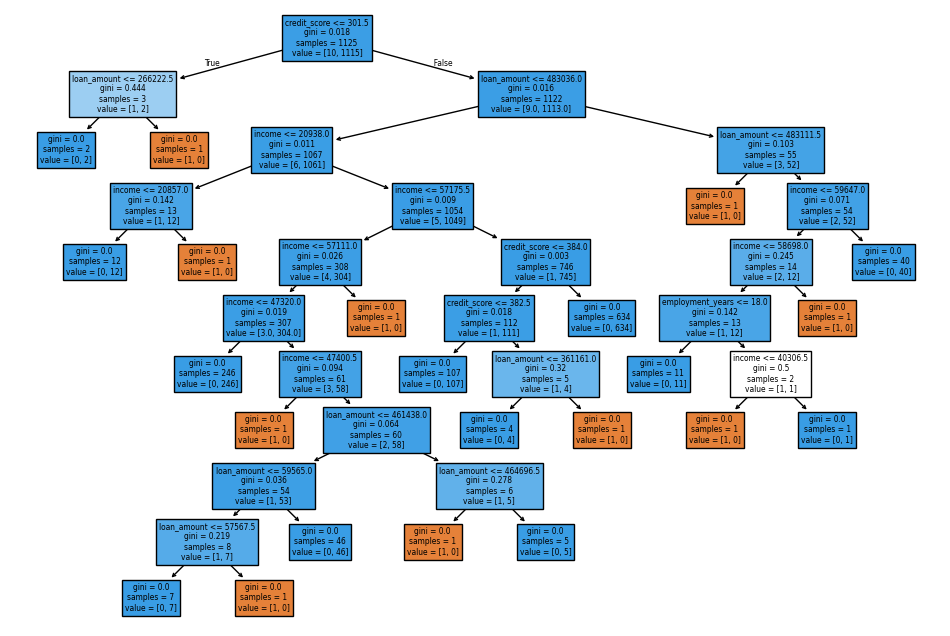

In [74]:
plt.figure(figsize=(12,8))
plot_tree(model,feature_names=X.columns,filled=True)
plt.show()

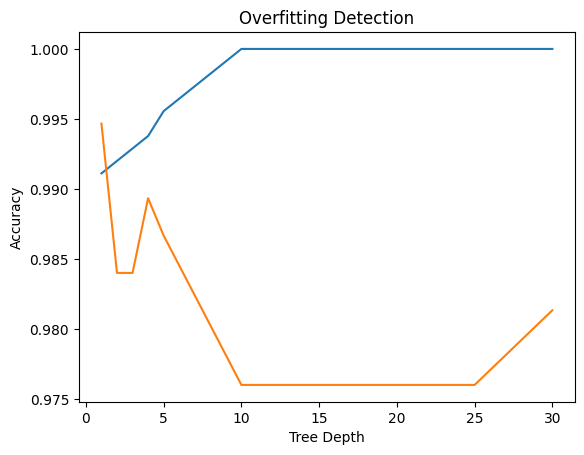

In [75]:
import matplotlib.pyplot as plt

depths = [1,2,3,4,5,10,20,25,30]
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train,y_train)
    
    train_scores.append(model.score(X_train,y_train))
    test_scores.append(model.score(X_test,y_test))

plt.plot(depths,train_scores)
plt.plot(depths,test_scores)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")

plt.title("Overfitting Detection")

plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
rf=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

In [78]:
rf_acc = accuracy_score(y_test,rf_pred)

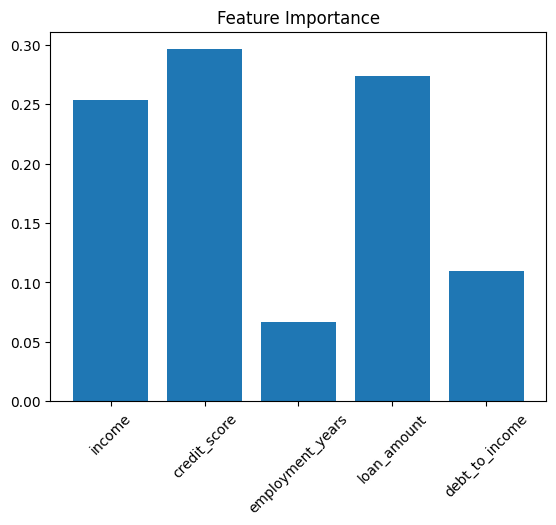

In [79]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

plt.bar(X.columns, importance)

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

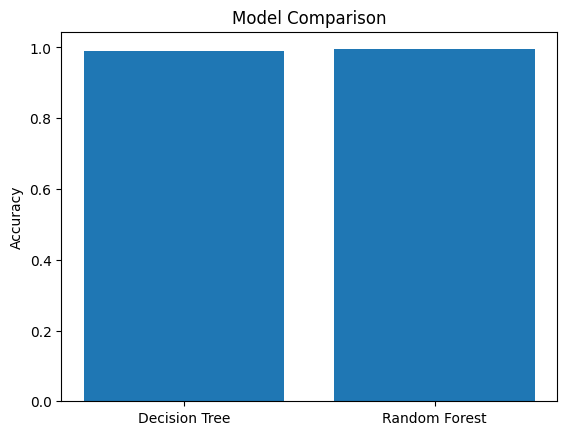

In [80]:
models = ["Decision Tree","Random Forest"]
scores = [tree_acc, rf_acc]

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()